In [1]:
#Import the pandas library
import pandas as pd

In [2]:
#Read the CSV file into a DataFrame
input_file="/content/iris.csv"
df=pd.read_csv(input_file)

In [3]:
#First 5 rows of the dataset
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
#Bottom 5 rows of the datset
df.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [5]:
#Printing the number of rows and column in the dataset
print("The number of rows in the dataset",df.shape[0])
print("The number of columns in the dataset",df.shape[1])

The number of rows in the dataset 150
The number of columns in the dataset 5


In [6]:
#Check for missing values in the dataset
df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


In [7]:
#Check for duplicate rows
print(df.duplicated().sum())

3


In [8]:
#Drop duplicate rows from the dataset
df.drop_duplicates(inplace=True)

In [9]:
df.shape

(147, 5)

<Figure size 800x600 with 0 Axes>

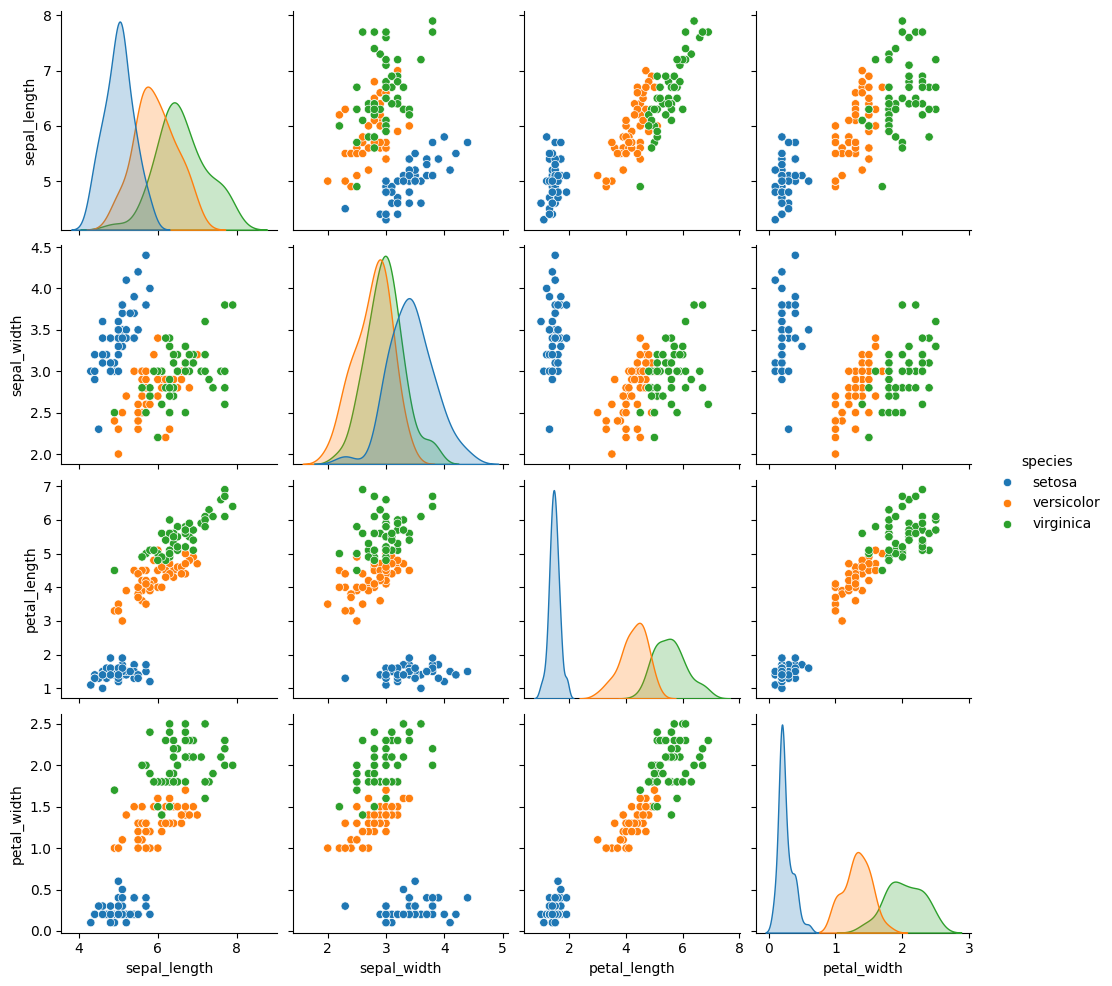

In [10]:
#Import the seaborn library
import seaborn as sns
#Importing the matplotlib library
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
#Create a pairplot to visualize relationships between features
sns.pairplot(df,hue="species")
plt.show()


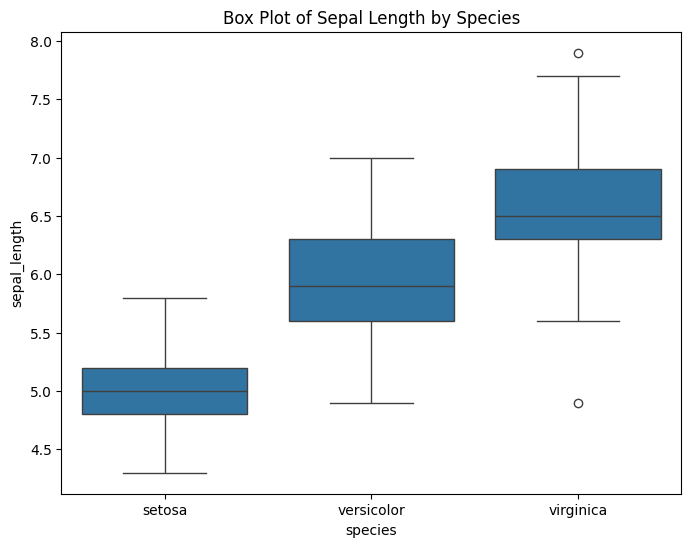

In [11]:
#Boxplot

#Setting the figure size
plt.figure(figsize=(8,6))
#Plotting the boxplot of Sepal Length by species
sns.boxplot(x='species', y='sepal_length', data=df)
#Set plot title
plt.title('Box Plot of Sepal Length by Species')
#Displaying the plot
plt.show()

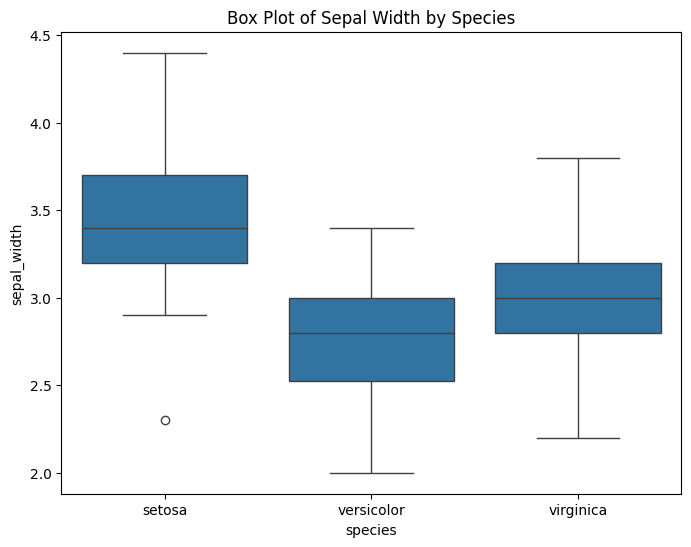

In [12]:
#Boxplot

#Setting the figure size
plt.figure(figsize=(8,6))
#Plotting the boxplot of Sepal Width by species
sns.boxplot(x='species', y='sepal_width', data=df)
#Set plot title
plt.title('Box Plot of Sepal Width by Species')
#Displaying the plot
plt.show()

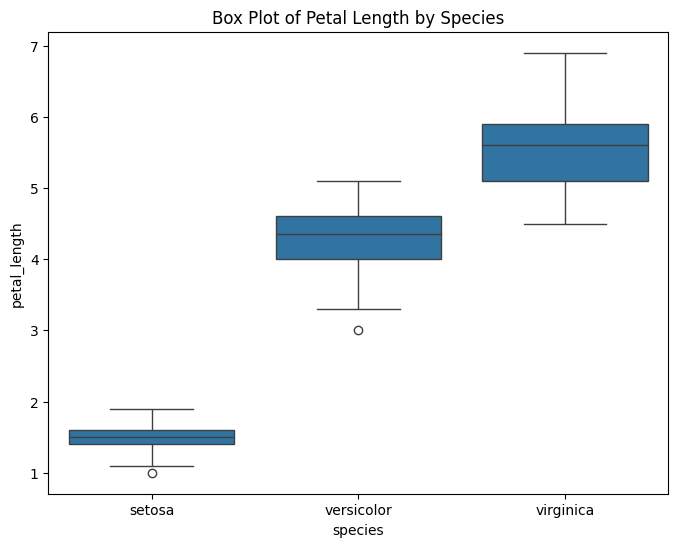

In [13]:
#Boxplot

#Setting the figure size
plt.figure(figsize=(8,6))
#Plotting the boxplot of Petal Length by species
sns.boxplot(x='species', y='petal_length', data=df)
#Set plot title
plt.title('Box Plot of Petal Length by Species')
#Displaying the plot
plt.show()

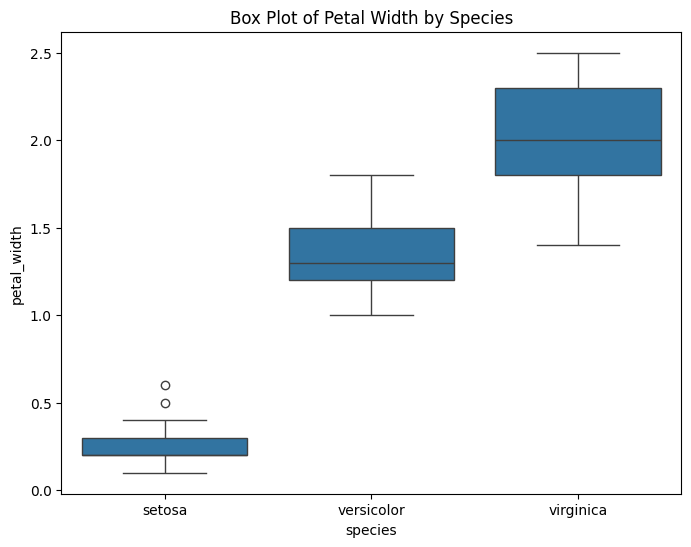

In [14]:
#Boxplot

#Setting the figure size
plt.figure(figsize=(8,6))
#Plotting the boxplot of Petal Width by species
sns.boxplot(x='species', y='petal_width', data=df)
#Set plot title
plt.title('Box Plot of Petal Width by Species')
#Displaying the plot
plt.show()

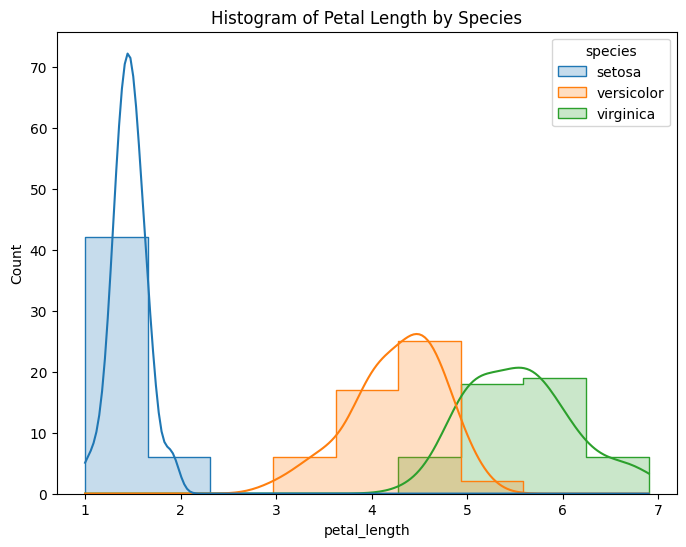

In [15]:
# Histogram of Petal Length by Species

#Setting the figure size
plt.figure(figsize=(8,6))
#Plotting the histogram
sns.histplot(data=df, x='petal_length', hue='species', kde=True, element='step')
#Set plot title
plt.title('Histogram of Petal Length by Species')
#Displaying the plot
plt.show()

In [16]:
#Getting the correlation matrix
corr = df.iloc[:, :-1].corr()
print(corr)

              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.109321      0.871305     0.817058
sepal_width      -0.109321     1.000000     -0.421057    -0.356376
petal_length      0.871305    -0.421057      1.000000     0.961883
petal_width       0.817058    -0.356376      0.961883     1.000000


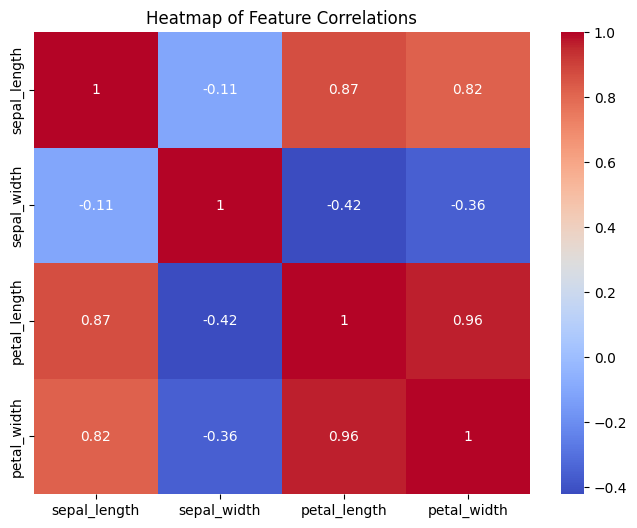

In [17]:
#Heatmap

#Setting the figure size
plt.figure(figsize=(8,6))
#plotting the heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm')
#Set plot title
plt.title('Heatmap of Feature Correlations')
#Displaying the plot
plt.show()

In [18]:
#Split the dataset into features(X) and target(y)
X=df.iloc[:,:-1] #features
y=df.iloc[:,-1] #target


In [19]:
#Encode the target variable (species) into numeric format
#Importing the label Encoder
from sklearn.preprocessing import LabelEncoder
#Create a LabelEncoder instance
le = LabelEncoder()
#Transforming the target variable into numerical variable
y_encoded = le.fit_transform(y)


In [20]:
#Importing the train test module
from sklearn.model_selection import train_test_split
#Splitting the dataset into training and testing subsets
X_train,X_test,y_train,y_test=train_test_split(X,y_encoded,test_size=0.25,random_state=42)

In [21]:
#Importing the Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

In [22]:
#Creating an instance of the Decision Tree Classifier
clf=DecisionTreeClassifier()

In [23]:
#Train the Decision Tree Classifier on the training data
clf.fit(X_train,y_train)

DecisionTreeClassifier()

In [24]:
#Predicting the X_test
y_pred=clf.predict(X_test)

In [25]:
#Importing the accuracy_score and classification_report
from sklearn.metrics import accuracy_score,classification_report
#Printing the accuracy_score
accuracy=accuracy_score(y_test,y_pred)
print(f"Accuracy : {accuracy:.2f}")

Accuracy : 0.97


In [26]:
#Printing the classification report
print('Classification Report:\n', classification_report(y_test, y_pred, target_names=le.classes_))

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        14
  versicolor       1.00      0.90      0.95        10
   virginica       0.93      1.00      0.96        13

    accuracy                           0.97        37
   macro avg       0.98      0.97      0.97        37
weighted avg       0.97      0.97      0.97        37



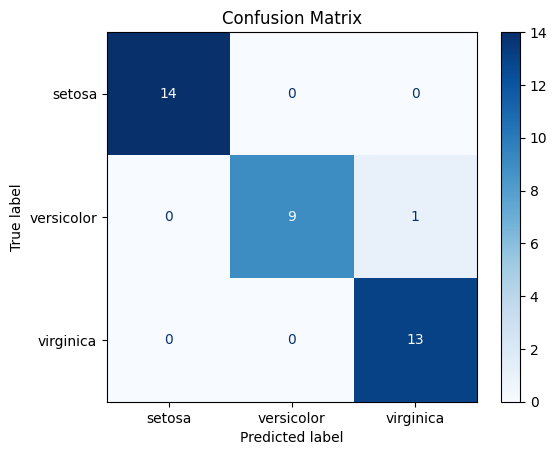

In [27]:
#Adding the confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, display_labels=le.classes_, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

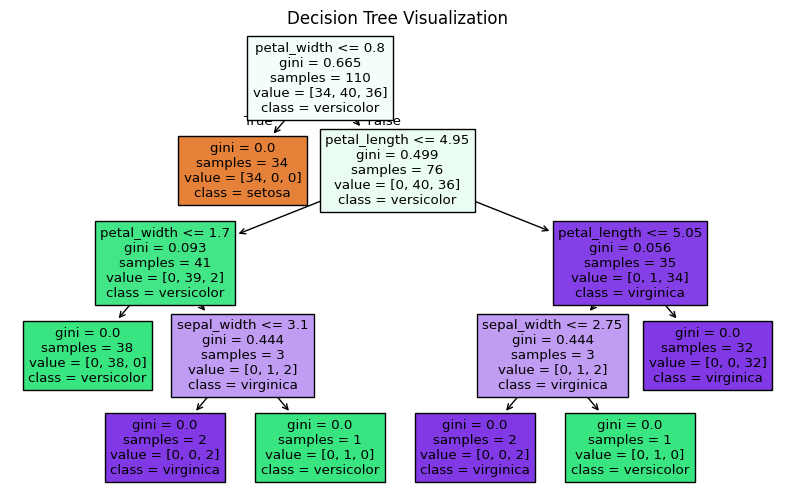

In [28]:
#Plotting the decision tree
from sklearn.tree import plot_tree

plt.figure(figsize=(10,6))
plot_tree(clf, feature_names=X.columns, class_names=le.classes_, filled=True)
plt.title("Decision Tree Visualization")
plt.show()

In [30]:
# Example: New input data for prediction
new_input = [[5.0, 3.4, 1.5, 0.2]]  # Format: [sepal_length, sepal_width, petal_length, petal_width]

# Predict using the trained model
predicted_class = clf.predict(new_input)

# Convert predicted numeric label back to species name
predicted_species = le.inverse_transform(predicted_class)

# Display the result
print("Predicted species for input", new_input, "is:", predicted_species[0])


Predicted species for input [[5.0, 3.4, 1.5, 0.2]] is: setosa


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# **Real-World Insight :**
# This model can assist botanists and researchers in classifying iris flowers quickly and accurately based on simple physical measurements. It reduces manual errors and speeds up species identification.
